In [2]:
import sqlite3
import sys
sys.path.append("../feature_extraction")
import pandas as pd
import query_library as qlib
from scipy.stats import binned_statistic
import croom_library as clib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import utility
from astropy.table import Table

In [3]:
coadd = qlib.query_coadd_photometry(keep_cmodel = False, keep_extendedness = True)
truth = qlib.query_truth_table(columns = "all")

In [4]:
table = coadd.merge(truth, on = "objectId", how = "inner")

In [5]:
iband_limit = 22
gband_limit = 21.85
table["label"] = utility.get_truth_label(table)
point_like = table[table["refExtendedness"] == 0]
point_like = table.copy()
colors = clib.get_colors(point_like, catalog ='photometric')
bright = (colors["g"]<=gband_limit) & (colors["i"]<=iband_limit)
colors = colors[bright]
colors["label"].value_counts()

label
0    3206
1    1196
3     120
2      37
Name: count, dtype: int64

In [6]:
def get_plot(ax, df, color1, color2, star_kwargs = {"color":"k", "s":1},
             type2_kwargs = {"color": "steelblue", "s":2}, 
             galaxy_kwargs = {"color": "steelblue", "s":2}, 
             type1_kwargs = {"color":"red", "s":40}):
    ax.scatter(df.loc[df["label"]==1, color1], df.loc[df["label"]==1, color2], **galaxy_kwargs)
    ax.scatter(df.loc[df["label"]==2, color1], df.loc[df["label"]==2, color2], **type2_kwargs)
    ax.scatter(df.loc[df["label"]==0, color1], df.loc[df["label"]==0, color2], **star_kwargs)
    ax.scatter(np.nan, np.nan, color = galaxy_kwargs["color"], s = 50, label = "Galaxy and AGN-Type2")
    ax.scatter(np.nan, np.nan, color = star_kwargs["color"], s = 50, label = "Star")
    ax.scatter(df.loc[df["label"]==3, color1], df.loc[df["label"]==3, color2], **type1_kwargs, label = "AGN-Type1")
    ax.set_xlabel(color1, fontsize = 17, labelpad = 0)
    ax.set_ylabel(color2, fontsize = 17, labelpad =0)
    ax.tick_params(axis = 'both', labelsize =11)

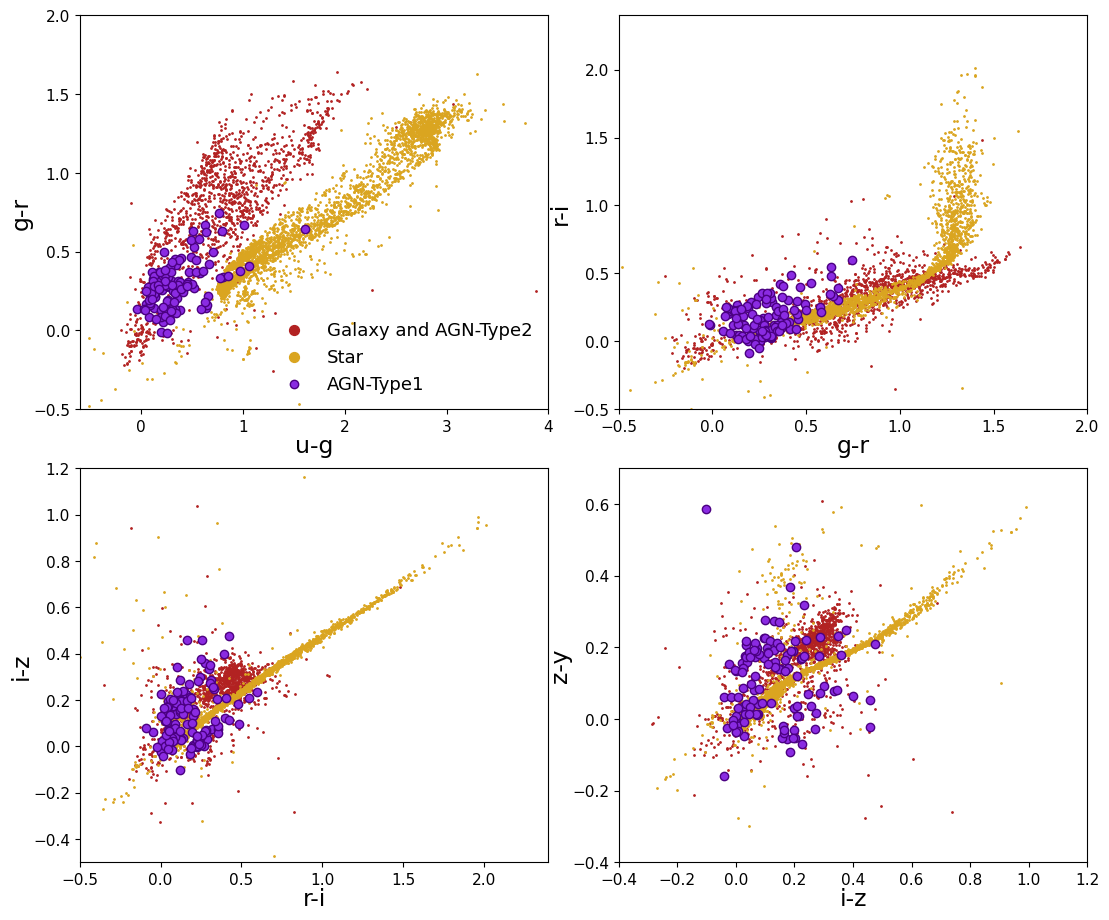

In [7]:
plot_colors = ["u-g", "g-r", "r-i", "i-z", "z-y"]
fig, axs = plt.subplots(2, 2, figsize = (13, 11), gridspec_kw={"wspace":0.15, "hspace":0.15})
for i, (color1, color2) in enumerate(zip(plot_colors[:-1], plot_colors[1:])):
    row = i // 2
    col = i % 2
    get_plot(axs[row, col], colors, color1, color2, galaxy_kwargs={"color":"firebrick", 's':1},
             type2_kwargs={"color":"firebrick", 's':1}, star_kwargs = {"color":"goldenrod", "s":1}, 
             type1_kwargs={"color":"blueviolet", "marker":"o", "edgecolor": "indigo"})
axs[0, 0].set_xlim(-0.6, 4)
axs[0, 0].set_ylim(-0.5, 2)
axs[0, 1].set_xlim(-0.5, 2)
axs[0, 1].set_ylim(-0.5, 2.4)
axs[1, 0].set_xlim(-0.5, 2.4)
axs[1, 0].set_ylim(-0.5, 1.2)
axs[1, 1].set_xlim(-0.4, 1.2)
axs[1, 1].set_ylim(-0.4, 0.7)
axs[0,0].legend(frameon = False, fontsize = 13)
#plt.savefig("../plot/color_color_also_ext.pdf", bbox_inches = "tight")


In [8]:
croom_result  =  clib.apply_croom09(colors, i_band_limit=iband_limit, g_band_limit=gband_limit)

In [10]:
Nselected =  np.sum(croom_result["is_croom_agn"] & (croom_result["label"]==3))
Nwrong =  np.sum(croom_result["is_croom_agn"] & ~(croom_result["label"]==3))
Ntot =  np.sum(croom_result["label"]==3)
precision = Nselected /  np.sum(croom_result["is_croom_agn"])
print(Nselected, Ntot, Nselected/Ntot, Nwrong, precision)

77 120 0.6416666666666667 196 0.28205128205128205


In [20]:
df = table.merge(croom_result[["ID", "is_croom_agn"]], how = "right", on = "ID")
df["agn_fraction_r"] = df["lsst-r_point"]/df["lsst-r_total"]
df.loc[df["label"] <2,  "agn_fraction_r"] = np.nan

In [23]:
cuts = [5, 7.5, 10]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, parameter_name = "MBH", bins = cuts,
                                                     selected_name = "is_croom_agn")
print(completeness)
#print(1-precision)
print(N, completeness*N)

print("###################")


cuts = [-3, -1, 0, 1, 3]
completeness, precision, N, _ = utility.get_completeness_precision_curve(df, parameter_name = "log_lambda_Edd", bins = cuts,
                                                     selected_name = "is_croom_agn")
print(completeness)
#print(1-precision)
print(N, completeness*N)


[0.65079365 0.63157895]
[63 57] [41. 36.]
###################
[0.55555556 0.6744186  0.69565217 0.5       ]
[ 9 43 46 22] [ 5. 29. 32. 11.]


(array([16.,  7.,  1.,  0.,  1.,  2.,  0.,  3.,  3.,  1.,  5.,  0.,  4.,
         5.,  3.,  4.,  1., 10.,  9., 35., 47.]),
 array([-0.04,  0.01,  0.06,  0.11,  0.16,  0.21,  0.26,  0.31,  0.36,
         0.41,  0.46,  0.51,  0.56,  0.61,  0.66,  0.71,  0.76,  0.81,
         0.86,  0.91,  0.96,  1.01]),
 <BarContainer object of 21 artists>)

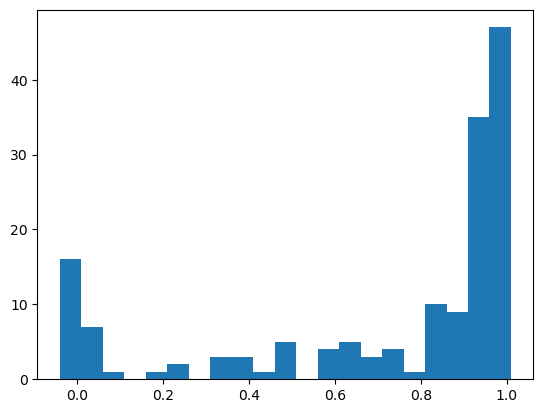

In [24]:
bins = np.arange(-0.04, 1.05, 0.05)
plt.hist(df["agn_fraction_r"], bins = bins)

In [ ]:
df[label == ]

,objectId,refExtendedness,detect_isPrimary,u_psfFlux,u_psfFluxErr,u_psfFlux_flag,u_extendedness,u_extendedness_flag,g_psfFlux,g_psfFluxErr,...,magabs_vista-Ks_total,pmracosd,pmdec,is_lsst_any_30s,is_lsst_any_10yr,is_lsst_all_30s,is_lsst_all_10yr,label,is_croom_agn,agn_fraction_r
0,4229179117263650995,0.0,1,5700.517684,150.422733,0,0.0,0,12188.512206,47.383515,...,NaN,0.25,-2.75,1,1,1,1,0,False,1.0
1,4229179117263654543,0.0,1,17152.350704,160.488786,0,0.0,0,49082.842725,59.115970,...,NaN,1.47,-5.11,1,1,1,1,0,False,1.0
2,4229179117263654669,0.0,1,28663.710327,169.941360,0,0.0,0,72785.710477,72.192738,...,NaN,2.80,-7.67,1,1,1,1,0,False,1.0
3,4229179117263654761,0.0,1,2365.354998,99.196914,0,0.0,0,34735.947933,37.403584,...,NaN,-7.15,-8.49,1,1,1,1,0,False,1.0
4,4229179117263654774,0.0,1,2473.825105,111.605600,0,1.0,0,7976.653273,37.702262,...,NaN,-0.39,-4.61,1,1,1,1,0,False,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4554,4229566145356651807,1.0,1,12179.627940,41.523028,0,1.0,0,16074.782230,12.436985,...,-24.010929,NaN,NaN,1,1,1,1,1,True,0.0
4555,4229566145356651816,0.0,1,1447.132967,37.380226,0,1.0,0,16767.293197,12.069512,...,NaN,0.43,-2.46,1,1,1,1,0,False,1.0
4556,4229566145356651924,1.0,1,6920.248553,39.564761,0,1.0,0,11598.012575,11.871441,...,-25.764164,NaN,NaN,1,1,1,1,1,False,0.0
4557,4229566145356651989,0.0,1,4281.836735,38.267449,0,0.0,0,9024.456786,11.366667,...,NaN,-0.87,-3.11,1,1,1,1,0,False,1.0


In [157]:
def get_croom_numbers(table):
    flag = table["is_croom_quality"]
    is_type1 = (table["label"] == 3) & flag
    is_low_z = is_type1 & (table["Z"] < 2.6)
    is_low_z = is_type1 & (table["Z"] < 2.6) 
    true_selected = is_low_z & table["is_croom_agn"]
    false_selected = (table["is_croom_agn"]) & ~is_type1
    false_selected = false_selected & flag
    return np.sum(is_type1),np.sum(is_low_z),  np.sum(true_selected), np.sum(false_selected)

In [158]:
N1, Nlow, tp, fp = get_croom_numbers(croom_result)

In [136]:
np.sum(croom_result["is_croom_agn"] & (croom_result["label"]==0))

np.int64(18)

In [160]:
table = Table.from_pandas(croom_result)
table.write("../table_output/croom_selection.fits")

In [137]:
agn = croom_result[croom_result["label"]==3]

In [144]:
np.sum(agn["g"]>=20.5)

np.int64(50)

In [145]:
np.sum((agn["g"]>=20.5) & agn["is_croom_agn"])

np.int64(27)

In [ ]:
27/40

0.9375

In [143]:
27+15

42